# QAOA for MaxCut

Solve MaxCut on a five-node graph with QAOA and compare against brute force. The code lives in `src/qaoa_maxcut.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
import networkx as nx

from src.qaoa_maxcut import brute_force_maxcut, qaoa_circuit, solve

brute-force maximum cut: 6.0


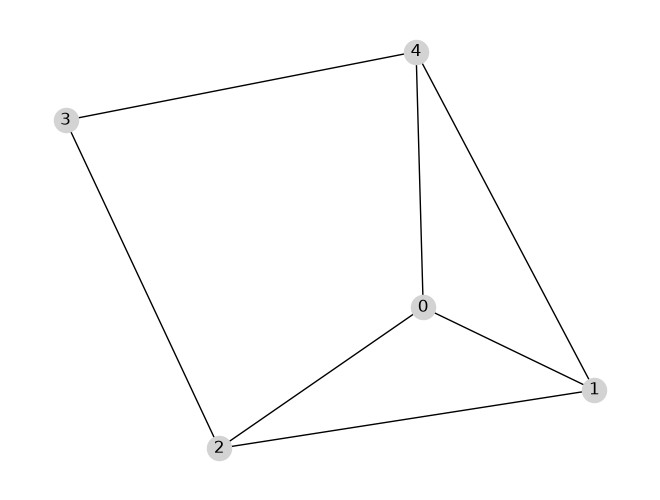

In [2]:
graph = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2), (1, 4)])
pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, with_labels=True, node_color="lightgray")
print("brute-force maximum cut:", brute_force_maxcut(graph))

One QAOA layer: a ZZ rotation per edge (cost), then an X rotation per node (mixer).

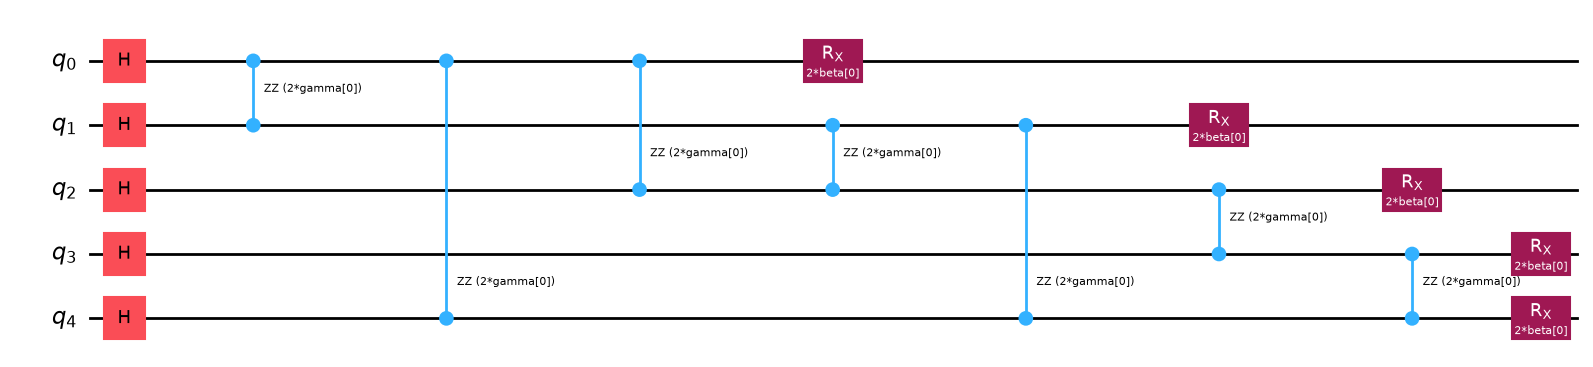

In [3]:
qaoa_circuit(graph, reps=1).draw("mpl", fold=-1)

cut value 6, expected cut 5.336, P(best) 61.0%


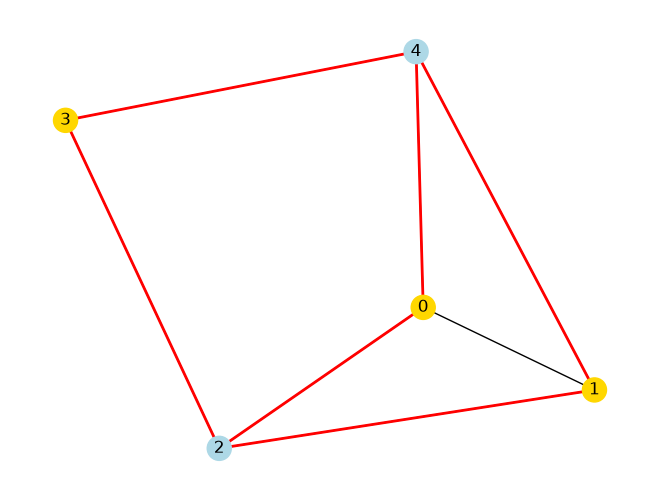

In [4]:
result = solve(graph, reps=2, seed=1)
print(f"cut value {result.cut_value:g}, expected cut {result.expected_cut:.3f}, P(best) {result.best_probability:.1%}")

colors = ["gold" if result.assignment[node] else "lightblue" for node in graph.nodes]
cut = [(u, v) for u, v in graph.edges if result.assignment[u] != result.assignment[v]]
nx.draw(graph, pos, with_labels=True, node_color=colors)
nx.draw_networkx_edges(graph, pos, edgelist=cut, edge_color="red", width=2);

## More layers

In principle more layers can only help, because the optimiser could set the extra angles to zero. In practice COBYLA can settle in a worse local minimum, so a larger p does not always win on a single run.

In [5]:
for reps in (1, 2, 3):
    r = solve(graph, reps=reps, seed=1)
    print(f"p = {reps}: expected cut {r.expected_cut:.3f}, P(best cut) {r.best_probability:.1%}")

p = 1: expected cut 4.600, P(best cut) 25.5%


p = 2: expected cut 5.336, P(best cut) 61.0%


p = 3: expected cut 5.152, P(best cut) 53.1%
